In [1]:
!pip install wfdb

In [2]:
# IMPORTATIONS
import sys
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE  # Ajout SMOTE

# 1. VERSIONS
print('\n=== VERSIONS DES LIBRAIRIES ===')
print(f"Python: {sys.version.split()[0]}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"wfdb: {wfdb.__version__}")


=== VERSIONS DES LIBRAIRIES ===
Python: 3.11.12
numpy: 2.0.2
pandas: 2.2.3
wfdb: 4.3.0


In [3]:
# 2. CHARGEMENT DES DONNEES
def load_ecg_data(record_names):
    signals = []
    labels = []
    for record in record_names:
        try:
            signal, _ = wfdb.rdsamp(record, pn_dir='mitdb')
            annotation = wfdb.rdann(record, 'atr', pn_dir='mitdb')
            for i in range(len(annotation.sample)):
                start = max(0, annotation.sample[i] - 100)
                end = min(len(signal), annotation.sample[i] + 100)
                beat = signal[start:end, 0]
                if len(beat) < 200:
                    beat = np.pad(beat, (0, 200 - len(beat)), mode='constant')
                else:
                    beat = beat[:200]
                if annotation.symbol[i] in ['N', 'V', 'A']:
                    signals.append(beat)
                    labels.append(annotation.symbol[i])
        except Exception as e:
            print(f"Erreur avec {record}: {e}")
    return np.array(signals), np.array(labels)

print('CHARGEMENT DES DONNEES ECG Réussi')
# Charger plus d'enregistrements pour équilibrer
record_names = [str(i) for i in range(100, 110)]
X, y = load_ecg_data(record_names)

CHARGEMENT DES DONNEES ECG Réussi



=== EXPLORATION DES DONNEES BRUTES ===
Statistiques globales brutes :
- Nombre total de battements : 12939
- Forme des données : (12939, 200)

Distribution des classes originales :
N    12215
V      682
A       42
Name: count, dtype: int64


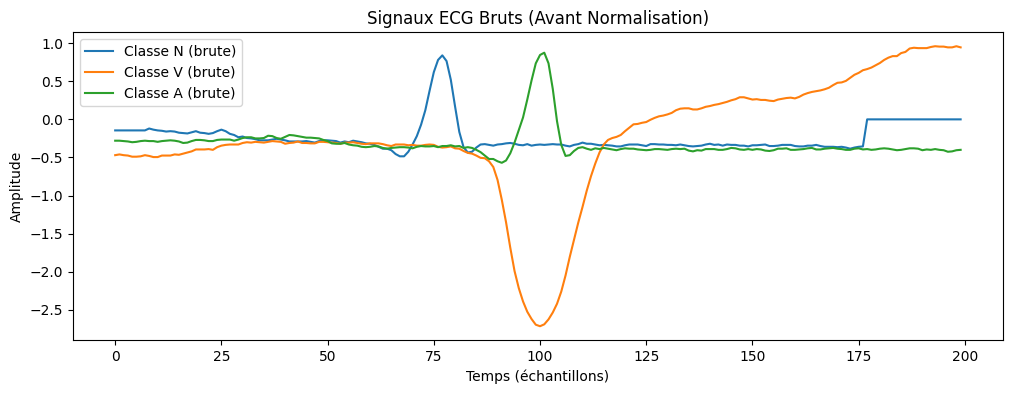

In [4]:
# 3. EXPLORATION DES DONNEES BRUTES (AVANT NORMALISATION)
print('\n=== EXPLORATION DES DONNEES BRUTES ===')
print("Statistiques globales brutes :")
print(f"- Nombre total de battements : {len(X)}")
print(f"- Forme des données : {X.shape}")
print("\nDistribution des classes originales :")
print(pd.Series(y).value_counts())

# Visualisation des signaux bruts
plt.figure(figsize=(12, 4))
for i, class_name in enumerate(['N', 'V', 'A']):
    idx = np.where(y == class_name)[0][0]
    plt.plot(X[idx], label=f'Classe {class_name} (brute)')
plt.title("Signaux ECG Bruts (Avant Normalisation)")
plt.xlabel("Temps (échantillons)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [5]:
print('\n=== NORMALISATION ===')
scaler = StandardScaler()
X_normalized = np.array([scaler.fit_transform(x.reshape(-1, 1)).flatten() for x in X])

# Encodage des labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


=== NORMALISATION ===



=== EXPLORATION DES DONNEES NORMALISEES ===
Statistiques post-normalisation :
- Moyenne : 0.00
- Écart-type : 1.00


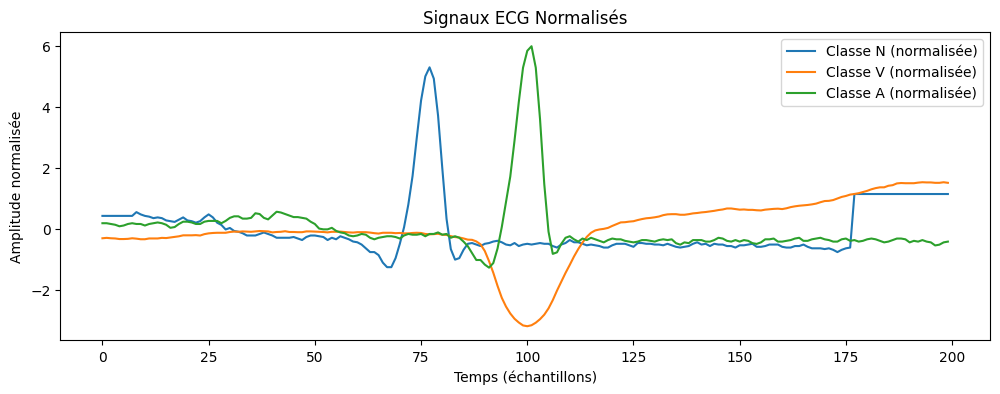


=== RÉÉQUILIBRAGE DES CLASSES ===

Distribution des classes après rééquilibrage :
1    12215
0    12215
2    12215
Name: count, dtype: int64

Répartition détaillée :
- Classe N (ID 1) : 12215 échantillons
- Classe A (ID 0) : 12215 échantillons
- Classe V (ID 2) : 12215 échantillons


In [6]:
# 5. EXPLORATION DES DONNEES NORMALISEES
print('\n=== EXPLORATION DES DONNEES NORMALISEES ===')
print("Statistiques post-normalisation :")
print(f"- Moyenne : {np.mean(X_normalized[0]):.2f}")
print(f"- Écart-type : {np.std(X_normalized[0]):.2f}")

# Visualisation des signaux normalisés
plt.figure(figsize=(12, 4))
for i, class_name in enumerate(['N', 'V', 'A']):
    idx = np.where(y == class_name)[0][0]
    plt.plot(X_normalized[idx], label=f'Classe {class_name} (normalisée)')
plt.title("Signaux ECG Normalisés")
plt.xlabel("Temps (échantillons)")
plt.ylabel("Amplitude normalisée")
plt.legend()
plt.show()

# 6. RÉÉQUILIBRAGE AVEC SMOTE
print('\n=== RÉÉQUILIBRAGE DES CLASSES ===')
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_normalized, y_encoded)

# Afficher le nombre d'échantillons par classe après SMOTE
print("\nDistribution des classes après rééquilibrage :")
class_counts = pd.Series(y_resampled).value_counts()
print(class_counts)

# Optionnel : Afficher sous forme de tableau avec les noms de classes
class_names = le.inverse_transform(class_counts.index)
print("\nRépartition détaillée :")
for class_id, count, name in zip(class_counts.index, class_counts.values, class_names):
    print(f"- Classe {name} (ID {class_id}) : {count} échantillons")


=== EVALUATION DES MODELES ===
Random Forest: Accuracy = 0.999 (±0.000)
SVM: Accuracy = 0.994 (±0.001)


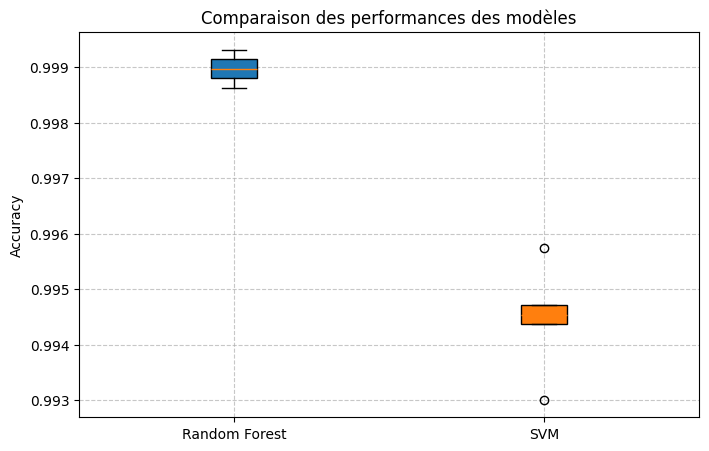

In [10]:
# 6. MODELISATION
print('\n=== EVALUATION DES MODELES ===')
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('SVM', SVC(kernel='rbf', probability=True, random_state=42))
]

results = []
for name, model in models:
    try:
        kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
        results.append(cv_scores)
        print(f"{name}: Accuracy = {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    except Exception as e:
        print(f"Erreur avec {name}: {str(e)}")

# Visualisation
plt.figure(figsize=(8, 5))
boxplot = plt.boxplot(results, patch_artist=True)  # Suppression du paramètre labels

# Configuration des ticks avec les noms des modèles
plt.xticks([1, 2], [name for name, _ in models])  # Utilisation de xticks à la place

plt.title("Comparaison des performances des modèles")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)

# Optionnel : Ajout de couleurs pour améliorer la lisibilité
colors = ['#1f77b4', '#ff7f0e']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

In [11]:
# 7. ENTRAINEMENT DU MODELE FINAL
print('\n=== ENTRAINEMENT DU MODELE FINAL ===')
best_model = RandomForestClassifier(n_estimators=100,random_state=42)
best_model.fit(X_train, y_train)

# 8. EVALUATION FINALE
print('\n=== RESULTATS FINAUX ===')
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de classification:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


=== ENTRAINEMENT DU MODELE FINAL ===

=== RESULTATS FINAUX ===
Accuracy: 0.99890844589985

Matrice de confusion:
[[2443    0    0]
 [   1 2436    6]
 [   0    1 2442]]

Rapport de classification:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      2443
           N       1.00      1.00      1.00      2443
           V       1.00      1.00      1.00      2443

    accuracy                           1.00      7329
   macro avg       1.00      1.00      1.00      7329
weighted avg       1.00      1.00      1.00      7329



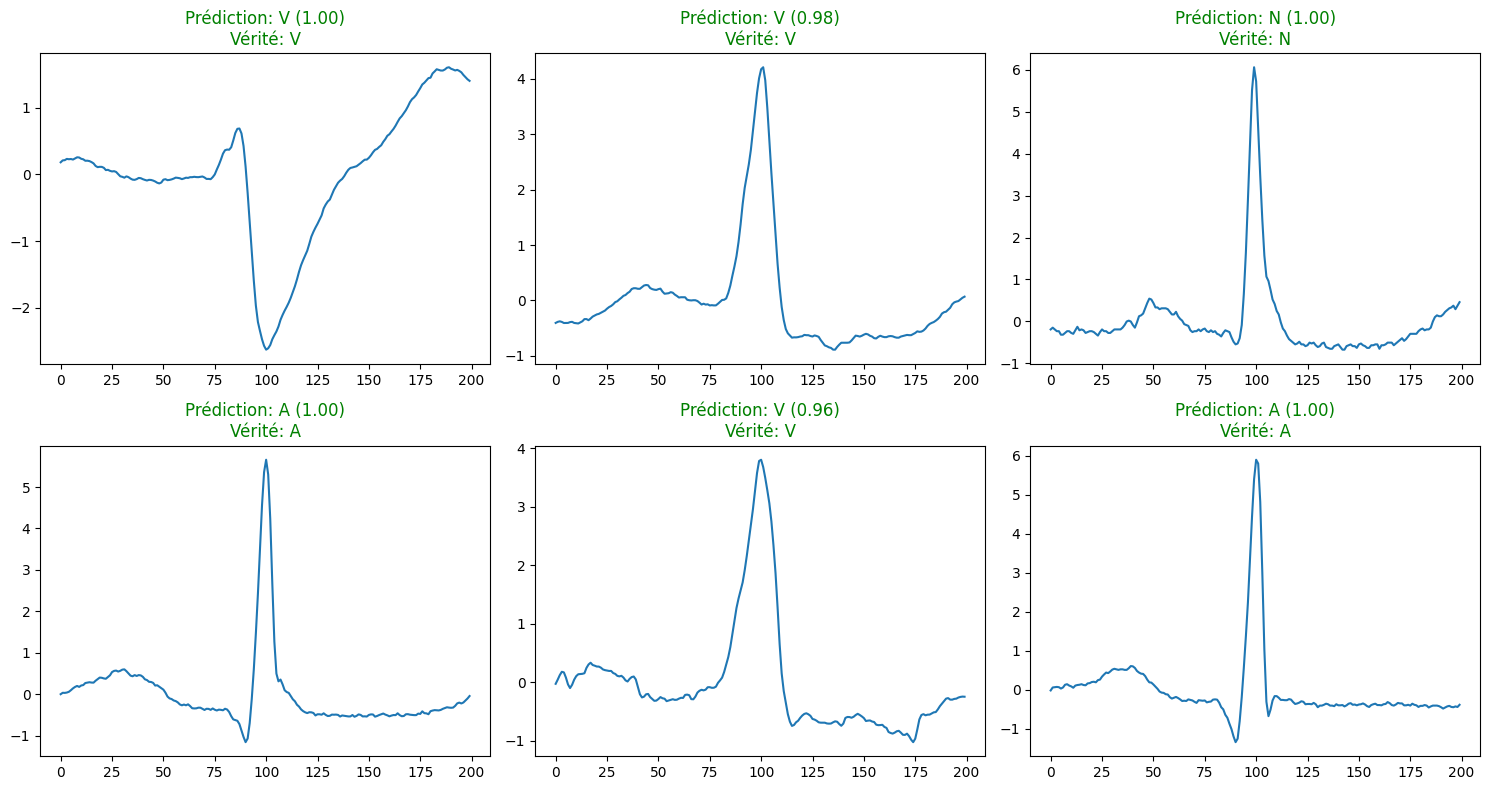

In [12]:
# 9. VISUALISATION DES PREDICTIONS
plt.figure(figsize=(15, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.plot(X_test[i])
    pred_class = le.inverse_transform([y_pred[i]])[0]
    true_class = le.inverse_transform([y_test[i]])[0]
    proba = y_proba[i].max()
    color = 'green' if pred_class == true_class else 'red'
    plt.title(f"Prédiction: {pred_class} ({proba:.2f})\nVérité: {true_class}", color=color)
plt.tight_layout()
plt.show()